# 实验 27:Faster R-CNN简化版实现行人检测

**实验性质**：设计性实验 (Design Experiment)  
**核心模型**：Faster R-CNN (ResNet-50 + FPN)  
**关键技术**：Transfer Learning, Region Proposal Network (RPN), Non-Maximum Suppression (NMS)  
**数据集**：Penn-Fudan Database for Pedestrian Detection

## 1. 实验背景与意义

### 知识点简述
**Faster R-CNN** 是双阶段目标检测（Two-Stage Object Detection）的里程碑式算法。
1. **第一阶段 (RPN)**：在特征图上生成候选框 (Region Proposals)，告诉网络“哪里可能有物体”。
2. **第二阶段 (ROI Head)**：对候选框进行分类（是人还是背景？）和坐标回归（修正框的位置）。

### 设计意义
本实验不从零手写卷积层，而是基于 `torchvision` 提供的模块化接口进行**架构设计与微调**。
学生需要掌握：
1.  **数据转换**：目标检测的数据集格式（Bounding Box）与分类任务完全不同，如何自定义 Dataset 类？
2.  **模型改造**：如何将预训练的 91 类（COCO数据集）检测器改造为 2 类（背景+行人）检测器？
3.  **结果解析**：理解检测模型的输出（Boxes, Labels, Scores）并进行可视化。


In [1]:
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.transforms import functional as F
from torch.utils.data import Dataset, DataLoader
import os
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import requests
import zipfile

# 设置随机种子
torch.manual_seed(1234)
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f'Using device: {device}')


Using device: cuda


## 2. 数据集准备 (Penn-Fudan Pedestrian)
我们将自动下载宾夕法尼亚大学的行人数据集。该数据集包含 170 张图片，每张图片都有对应的 Segmentation Mask（掩膜）。
**设计挑战**：Faster R-CNN 需要的是矩形框 (x_min, y_min, x_max, y_max)，而数据集提供的是不规则的掩膜。我们需要编写代码将掩膜转换为矩形框。


In [3]:
import os
import requests
import zipfile

# 1. 定义 data 文件夹的路径 (相对路径：上一级目录下的 data)
BASE_DATA_DIR = os.path.join('..', 'data')

# 2. 确保 data 文件夹存在，如果不存在则创建
if not os.path.exists(BASE_DATA_DIR):
    os.makedirs(BASE_DATA_DIR)
    print(f'已创建数据目录: {os.path.abspath(BASE_DATA_DIR)}')

# 3. 定义最终的数据集目录名和压缩包路径
# 注意：解压后的文件夹名通常是 PennFudanPed
DATA_DIR_NAME = 'PennFudanPed'
DATA_DIR_PATH = os.path.join(BASE_DATA_DIR, DATA_DIR_NAME)

ZIP_URL = 'https://www.cis.upenn.edu/~jshi/ped_html/PennFudanPed.zip'
ZIP_FILE_PATH = os.path.join(BASE_DATA_DIR, 'PennFudanPed.zip')

def download_data():
    # 检查解压后的文件夹是否存在
    if os.path.exists(DATA_DIR_PATH):
        print(f' 数据集已存在于: {os.path.abspath(DATA_DIR_PATH)}')
        print('跳过下载。')
        return
    
    # 检查压缩包是否已经存在 (避免重复下载)
    if not os.path.exists(ZIP_FILE_PATH):
        print(f'正在下载数据集到 {ZIP_FILE_PATH} (约 50MB)...')
        try:
            r = requests.get(ZIP_URL, stream=True)
            with open(ZIP_FILE_PATH, 'wb') as f:
                for chunk in r.iter_content(chunk_size=1024):
                    if chunk: f.write(chunk)
            print('下载完成。')
        except Exception as e:
            print(f' 下载失败: {e}')
            print(f'请手动下载并放入目录: {os.path.abspath(BASE_DATA_DIR)}')
            return
    else:
        print(f'检测到本地压缩包: {ZIP_FILE_PATH}')

    # 解压逻辑
    print('正在解压...')
    try:
        with zipfile.ZipFile(ZIP_FILE_PATH, 'r') as zip_ref:
            # extractall 的路径设为 BASE_DATA_DIR
            # 这样解压出来的 PennFudanPed 文件夹就会在 ../data/ 下面
            zip_ref.extractall(BASE_DATA_DIR)
        print(f' 解压完成！数据位置: {os.path.abspath(DATA_DIR_PATH)}')
    except Exception as e:
        print(f' 解压失败: {e}')

download_data()

 数据集已存在于: d:\project2\27-Faster-Rcnn\data\PennFudanPed
跳过下载。


### 2.1 定义 Dataset 类
这是本实验最关键的**设计环节**。我们需要重写 `__getitem__` 方法：
1. 加载图片和掩膜。
2. 将掩膜（Mask）解析为边界框（Bounding Box）。
3. 转换为 Tensor 格式。


In [4]:
class PennFudanDataset(Dataset):
    def __init__(self, root, transforms=None):
        self.root = root
        self.transforms = transforms
        # 排序确保图片和掩膜一一对应
        self.imgs = list(sorted(os.listdir(os.path.join(root, "PNGImages"))))
        self.masks = list(sorted(os.listdir(os.path.join(root, "PedMasks"))))

    def __getitem__(self, idx):
        # 加载图片和掩膜
        img_path = os.path.join(self.root, "PNGImages", self.imgs[idx])
        mask_path = os.path.join(self.root, "PedMasks", self.masks[idx])
        img = Image.open(img_path).convert("RGB")
        mask = Image.open(mask_path)
        
        # 将 mask 转为 numpy 数组，mask 中 0 是背景，1, 2... 是不同的行人
        mask = np.array(mask)
        obj_ids = np.unique(mask)
        # 移除背景 id (0)
        obj_ids = obj_ids[1:]
        
        # 分割 mask 为一组二值 mask
        masks = mask == obj_ids[:, None, None]
        
        # 从 mask 获取 bounding box 坐标
        num_objs = len(obj_ids)
        boxes = []
        for i in range(num_objs):
            pos = np.where(masks[i])
            xmin = np.min(pos[1])
            xmax = np.max(pos[1])
            ymin = np.min(pos[0])
            ymax = np.max(pos[0])
            boxes.append([xmin, ymin, xmax, ymax])
        
        boxes = torch.as_tensor(boxes, dtype=torch.float32)
        labels = torch.ones((num_objs,), dtype=torch.int64) # 只有一类：行人 (Label=1)
        image_id = torch.tensor([idx])
        area = (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0])
        iscrowd = torch.zeros((num_objs,), dtype=torch.int64)
        
        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["image_id"] = image_id
        target["area"] = area
        target["iscrowd"] = iscrowd
        
        if self.transforms is not None:
            img = self.transforms(img)
            
        return img, target

    def __len__(self):
        return len(self.imgs)

# 简单的 transform：转 Tensor
def get_transform():
    return torchvision.transforms.ToTensor()


### 2.2 验证数据加载
在投入网络训练前，必须可视化检查 Box 是否正确框住了行人。


Image Shape: torch.Size([3, 536, 559])
Target Boxes: tensor([[159., 181., 301., 430.],
        [419., 170., 534., 485.]])


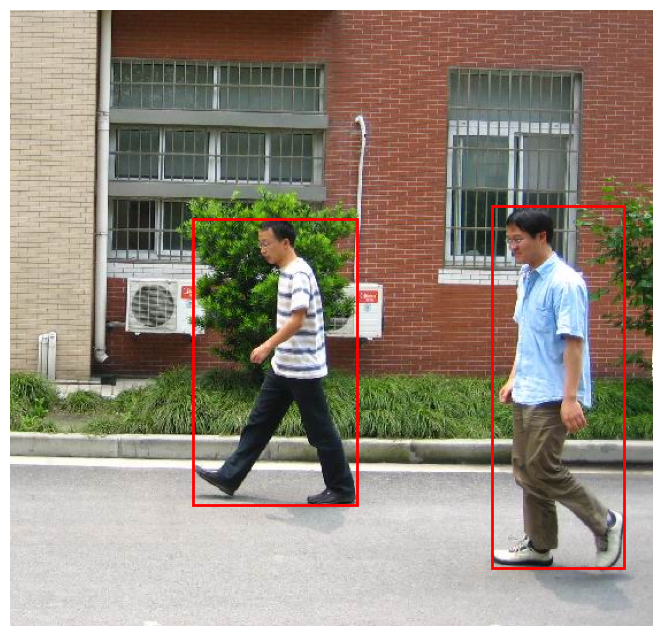

In [6]:
import os
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch

# 定义 DATA_DIR 
DATA_DIR = os.path.join('..', 'data', 'PennFudanPed')

def plot_image_with_boxes(img, boxes):
    plt.figure(figsize=(10,8))
    # Tensor (C, H, W) -> Numpy (H, W, C)
    plt.imshow(img.permute(1, 2, 0))
    ax = plt.gca()
    for box in boxes:
        x, y, x_max, y_max = box
        w, h = x_max - x, y_max - y
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='r', facecolor='none')
        ax.add_patch(rect)
    plt.axis('off')
    plt.show()

# 实例化数据集并取一张图测试
if os.path.exists(DATA_DIR):
    # 注意：这里假设 PennFudanDataset 和 get_transform 已经在前面的 Cell 定义过了
    dataset_test = PennFudanDataset(DATA_DIR, get_transform())
    
    # 获取第 0 张图片
    img, target = dataset_test[0]
    
    print(f"Image Shape: {img.shape}")
    print(f"Target Boxes: {target['boxes']}")
    
    # 绘图
    plot_image_with_boxes(img, target['boxes'])
else:
    print(f" 错误：找不到数据集路径: {os.path.abspath(DATA_DIR)}")
    print("请检查是否运行了上面的‘下载数据集’代码块。")

## 3. Faster R-CNN 模型微调 (Fine-tuning)
我们使用 `torchvision` 预训练的 `fasterrcnn_resnet50_fpn`。
**关键修改**：原模型是在 COCO 数据集 (91类) 上训练的。我们的任务只有 2 类（0:背景, 1:行人）。
我们需要**替换 Box Predictor (分类头)**。


In [7]:
def get_model_instance_segmentation(num_classes):
    # 1. 加载预训练模型 (Weights=Default 表示使用 COCO 权重)
    model = torchvision.models.detection.fasterrcnn_resnet50_fpn(weights="DEFAULT")
    
    # 2. 获取分类器的输入特征数
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    
    # 3. 替换预训练的头部 (Head)
    # 新的头部将只预测 num_classes 个类别
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)
    
    return model

# 类别数 = 1 (行人) + 1 (背景)
num_classes = 2
model = get_model_instance_segmentation(num_classes)
model.to(device)
print("模型架构修改完成！Head 已替换为 2 分类。")


Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to C:\Users\86177/.cache\torch\hub\checkpoints\fasterrcnn_resnet50_fpn_coco-258fb6c6.pth
100%|██████████| 160M/160M [00:27<00:00, 6.12MB/s] 


模型架构修改完成！Head 已替换为 2 分类。


## 4. 训练模型
注意：目标检测的数据集图片大小不一，无法直接 stack 起来。需要自定义 `collate_fn`。
为了证明模型的收敛性，我们需要记录每一次迭代的 Loss 值并绘制曲线。



In [8]:
def collate_fn(batch):
    return tuple(zip(*batch))

if os.path.exists(DATA_DIR):
    # 划分数据集：最后 50 张用于测试
    dataset = PennFudanDataset(DATA_DIR, get_transform())
    indices = torch.randperm(len(dataset)).tolist()
    
    dataset_train = torch.utils.data.Subset(dataset, indices[:-50])
    dataset_test = torch.utils.data.Subset(dataset, indices[-50:])
    
    data_loader = DataLoader(dataset_train, batch_size=2, shuffle=True, collate_fn=collate_fn)
    data_loader_test = DataLoader(dataset_test, batch_size=1, shuffle=False, collate_fn=collate_fn)
    
    # 优化器
    params = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.SGD(params, lr=0.005, momentum=0.9, weight_decay=0.0005)
    
    print(f"训练集大小: {len(dataset_train)} | 测试集大小: {len(dataset_test)}")


训练集大小: 120 | 测试集大小: 50


训练时间大概15分钟左右

In [16]:
num_epochs = 3
loss_history = []  # 用于记录每一步的 loss

if os.path.exists(DATA_DIR):
    for epoch in range(num_epochs):
        model.train()
        i = 0
        print(f"--- Epoch {epoch+1}/{num_epochs} ---")
        for images, targets in data_loader:
            images = list(image.to(device) for image in images)
            targets = [{k: v.to(device) for k, v in t.items()} for t in targets]
            
            loss_dict = model(images, targets)
            losses = sum(loss for loss in loss_dict.values())
            
            optimizer.zero_grad()
            losses.backward()
            optimizer.step()
            
            # 记录 Loss
            loss_value = losses.item()
            loss_history.append(loss_value)
            
            if i % 10 == 0:
                print(f"Iter {i}: Loss {loss_value:.4f}")
            i += 1
    
    print("训练完成！")


--- Epoch 1/3 ---
Iter 0: Loss 0.0928
Iter 10: Loss 0.1310
Iter 20: Loss 0.1231
Iter 30: Loss 0.0435
Iter 40: Loss 0.0549
Iter 50: Loss 0.0487
--- Epoch 2/3 ---
Iter 0: Loss 0.0285
Iter 10: Loss 0.0510
Iter 20: Loss 0.0246
Iter 30: Loss 0.0178
Iter 40: Loss 0.0465
Iter 50: Loss 0.0671
--- Epoch 3/3 ---
Iter 0: Loss 0.0463
Iter 10: Loss 0.0500
Iter 20: Loss 0.1116
Iter 30: Loss 0.0545
Iter 40: Loss 0.0330
Iter 50: Loss 0.0713
训练完成！


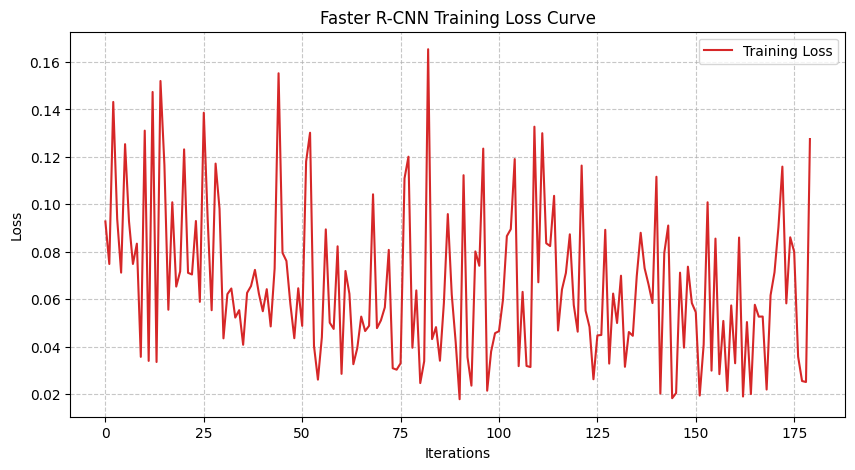

In [17]:
# 绘制训练 Loss 曲线
plt.figure(figsize=(10, 5))
plt.plot(loss_history, label='Training Loss', color='tab:red')
plt.title('Faster R-CNN Training Loss Curve')
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

## 5. 模型评估：精度-召回率曲线 (PR Curve)
不仅仅看几张图的预测结果，而是要定量分析。
我们将在测试集上计算 **IoU (Intersection over Union)**，并绘制 **Precision-Recall 曲线**。

**知识点**：
* **Precision (查准率)**: 预测为“行人”的框里，有多少真的是行人？
* **Recall (查全率)**: 真实图片里的“行人”，有多少被检测出来了？
* **AP (Average Precision)**: PR 曲线下的面积，是衡量检测器好坏的核心指标。


正在评估测试集 (计算 PR 曲线)...


d:\conda\miniconda\envs\project1\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 26597 (\N{CJK UNIFIED IDEOGRAPH-67E5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\conda\miniconda\envs\project1\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20934 (\N{CJK UNIFIED IDEOGRAPH-51C6}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\conda\miniconda\envs\project1\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\conda\miniconda\envs\project1\lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20840 (\N{CJK UNIFIED IDEOGRAPH-5168}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


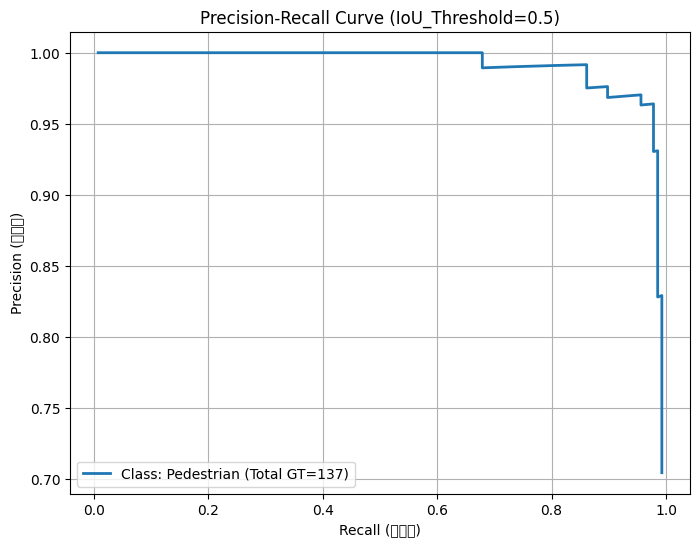

In [ ]:
def compute_iou(box1, box2):
    # box: [x1, y1, x2, y2]
    # 计算交集区域
    xx1 = max(box1[0], box2[0])
    yy1 = max(box1[1], box2[1])
    xx2 = min(box1[2], box2[2])
    yy2 = min(box1[3], box2[3])
    
    w = max(0, xx2 - xx1)
    h = max(0, yy2 - yy1)
    inter = w * h
    
    # 计算并集区域
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    
    return inter / union if union > 0 else 0

def evaluate_pr_curve(model, data_loader, device, iou_threshold=0.5):
    model.eval()
    all_predictions = []  # 存储 (score, is_tp)
    total_gt_boxes = 0
    
    print("正在评估测试集 (计算 PR 曲线)...")
    with torch.no_grad():
        for images, targets in data_loader:
            images = list(img.to(device) for img in images)
            outputs = model(images)
            
            # 遍历 batch 中的每一张图
            for i in range(len(images)):
                pred_boxes = outputs[i]['boxes'].cpu().numpy()
                pred_scores = outputs[i]['scores'].cpu().numpy()
                gt_boxes = targets[i]['boxes'].numpy()
                
                total_gt_boxes += len(gt_boxes)
                
                # 记录该图片中哪些 GT 已经被匹配过 (防止一个 GT 被多个预测框重复匹配)
                gt_matched = [False] * len(gt_boxes)
                
                # 按分数从高到低排序预测框
                sorted_indices = np.argsort(-pred_scores)
                for idx in sorted_indices:
                    p_box = pred_boxes[idx]
                    score = pred_scores[idx]
                    
                    # 寻找最大 IoU 的 GT
                    best_iou = 0
                    best_gt_idx = -1
                    
                    for gt_idx, g_box in enumerate(gt_boxes):
                        iou = compute_iou(p_box, g_box)
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = gt_idx
                    
                    # 判断是否为 TP (True Positive)
                    if best_iou >= iou_threshold and best_gt_idx != -1 and not gt_matched[best_gt_idx]:
                        all_predictions.append((score, 1)) # 1 = TP
                        gt_matched[best_gt_idx] = True
                    else:
                        all_predictions.append((score, 0)) # 0 = FP
                        
    # 计算 Accumulative Precision & Recall
    # 按分数排序
    all_predictions.sort(key=lambda x: x[0], reverse=True)
    
    TPs = [x[1] for x in all_predictions]
    acc_TP = np.cumsum(TPs)
    acc_FP = np.cumsum([1-x for x in TPs])
    
    recalls = acc_TP / total_gt_boxes
    precisions = acc_TP / (acc_TP + acc_FP)
    
    return recalls, precisions, total_gt_boxes

if os.path.exists(DATA_DIR):
    recalls, precisions, num_gt = evaluate_pr_curve(model, data_loader_test, device)
    
    # 绘图
    plt.figure(figsize=(8, 6))
    plt.plot(recalls, precisions, label=f'Class: Pedestrian (Total GT={num_gt})', linewidth=2)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve (IoU_Threshold=0.5)')
    plt.grid(True)
    plt.legend()
    plt.show()


## 6. 推理与结果可视化
模型输出包含 `boxes` (坐标), `labels` (类别), `scores` (置信度)。
我们需要设置一个**置信度阈值 (Threshold)**，例如 0.8，只显示高可信度的框，这就是 NMS (非极大值抑制) 的一部分。


In [19]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import random

# 确保已经定义了 show_inference 函数 (保持你原来的逻辑不变)
def show_inference(img_tensor, threshold=0.8):
    model.eval()
    with torch.no_grad():
        prediction = model([img_tensor.to(device)])
    
    # 移动回 CPU 处理
    boxes = prediction[0]['boxes'].cpu().numpy()
    scores = prediction[0]['scores'].cpu().numpy()
    
    # 筛选高置信度的框
    valid_indices = scores > threshold
    valid_boxes = boxes[valid_indices]
    valid_scores = scores[valid_indices]
    
    print(f"检测到 {len(valid_boxes)} 个目标 (阈值 {threshold})")
    
    # 绘图
    plt.figure(figsize=(10,8))
    # 修正：plt.imshow 需要 (H, W, C)，且 tensor 如果在 GPU 需先 .cpu()
    plt.imshow(img_tensor.permute(1, 2, 0).cpu()) 
    ax = plt.gca()
    
    for box, score in zip(valid_boxes, valid_scores):
        x, y, x_max, y_max = box
        w, h = x_max - x, y_max - y
        rect = patches.Rectangle((x, y), w, h, linewidth=2, edgecolor='g', facecolor='none')
        ax.add_patch(rect)
        ax.text(x, y-5, f"Person: {score:.2f}", color='white', backgroundcolor='green')
    plt.axis('off')
    plt.show()

# ================= 交互式部分 =================

# 1. 创建一个按钮
button = widgets.Button(
    description=' 随机抽取测试图',
    disabled=False,
    button_style='info', # 'success', 'info', 'warning', 'danger' or ''
    tooltip='点击从测试集中随机抽取一张图片并预测',
    icon='camera' # 图标
)

# 2. 创建一个输出区域 (用于显示图片)
output = widgets.Output()

# 3. 定义点击事件的回调函数
def on_button_clicked(b):
    with output:
        # 清除上一次的输出 (wait=True 表示直到新图画出来再清除旧图，防止闪烁)
        clear_output(wait=True)
        
        if os.path.exists(DATA_DIR):
            # 随机生成索引
            rand_idx = random.randint(0, len(dataset_test) - 1)
            print(f"正在预测测试集索引: [{rand_idx}] ...")
            
            # 获取图片
            img, target = dataset_test[rand_idx]
            
            # 调用预测函数
            show_inference(img, threshold=0.8)
        else:
            print(f"错误: 找不到数据集路径 {DATA_DIR}")

# 4. 绑定事件并显示
button.on_click(on_button_clicked)

print("请点击下方按钮开始测试：")
display(button, output)

请点击下方按钮开始测试：


Button(button_style='info', description=' 随机抽取测试图', icon='camera', style=ButtonStyle(), tooltip='点击从测试集中随机抽取一张…

Output()

## 7. 拓展与思考 (Interactive)
请思考以下问题，点击查看答案。

<details>
<summary style="cursor: pointer; font-weight: bold;"> 问题 1: 为什么 num_classes 设置为 2 而不是 1？</summary>
<div style="padding: 10px; margin-top: 5px;">
    <strong></strong> 目标检测必须包含一个<b>背景类 (Background)</b>。类别 0 通常保留给背景，类别 1 才是行人。如果设为 1，网络就无法区分“什么都没有”和“有人”了。
</div>
</details>

<br>

<details>
<summary style="cursor: pointer; font-weight: bold;"> 问题 2: Faster R-CNN 训练模式下的 Loss 包含哪几个部分？</summary>
<div style="padding: 10px; margin-top: 5px;">
    <strong></strong> 包含 4 个部分：<br>
    1. <b>RPN Objectness Loss</b>: RPN 判断是否有物体的误差。<br>
    2. <b>RPN Box Loss</b>: RPN 粗略修正建议框的误差。<br>
    3. <b>Classifier Loss</b>: 最终判断物体类别的误差。<br>
    4. <b>Box Regressor Loss</b>: 最终精修坐标框的误差。
</div>
</details>

<br>

<details>
<summary style="cursor: pointer; font-weight: bold;">问题 3: 如果 PR 曲线没有贴近右上角（即 Precision 和 Recall 不能同时很高），说明了什么？
</summary>
<div style="padding: 10px; margin-top: 5px;">
说明模型存在误检（FP多）或漏检（Recall低）。对于行人检测，可能原因是小目标检测困难，或者背景中存在类似行人的物体（如树干、电线杆）。</details>
